<a href="https://colab.research.google.com/github/MarcGaac/DSC1107/blob/main/FA_3_DSC1107.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install missing packages first (this might take a minute or two to run)
install.packages(c("ggrepel", "broom", "cowplot", "car", "performance"))

# Load required libraries
library(tidyverse)
library(ggrepel)
library(broom)
library(cowplot)
library(car)
library(performance)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘colorspace’, ‘fracdiff’, ‘lmtest’, ‘timeDate’, ‘urca’, ‘zoo’, ‘RcppArmadillo’, ‘Deriv’, ‘forecast’, ‘rbibutils’, ‘numDeriv’, ‘doBy’, ‘SparseM’, ‘MatrixModels’, ‘Rdpack’, ‘minqa’, ‘nloptr’, ‘reformulas’, ‘RcppEigen’, ‘carData’, ‘abind’, ‘Formula’, ‘pbkrtest’, ‘quantreg’, ‘lme4’, ‘bayestestR’, ‘insight’, ‘datawizard’



Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp


Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


The following object is masked from ‘package:purrr’:

    some




### 1.1 Import & Structure

In [ ]:
# Load the data. load() will pull the data into your environment.
loaded_objects <- load("ml_pay.rdata")
print(paste("The loaded object is named:", loaded_objects))

# The rubric requires the data to be named 'mlb_raw'.
# This grabs whatever the object was named in the file and assigns it to mlb_raw.
mlb_raw <- get(loaded_objects[1])

# Report dimensions (number of rows and columns)
print("Dimensions:")
dim(mlb_raw)

# Report variable types and structure
print("Structure:")
str(mlb_raw)

[1] "The loaded object is named: ml_pay"
[1] "Dimensions:"


[1] 30 54

[1] "Structure:"
'data.frame':	30 obs. of  54 variables:
 $ payroll       : num  1.12 1.38 1.16 1.97 1.46 ...
 $ avgwin        : num  0.49 0.553 0.454 0.549 0.474 ...
 $ Team.name.2014: Factor w/ 30 levels "Arizona Diamondbacks",..: 1 2 3 4 5 6 7 8 9 10 ...
 $ p1998         : num  31.6 61.7 71.9 59.5 49.8 ...
 $ p1999         : num  70.5 74.9 72.2 71.7 42.1 ...
 $ p2000         : num  81 84.5 81.4 77.9 60.5 ...
 $ p2001         : num  81.2 91.9 72.4 109.6 64 ...
 $ p2002         : num  102.8 93.5 60.5 108.4 75.7 ...
 $ p2003         : num  80.6 106.2 73.9 99.9 79.9 ...
 $ p2004         : num  70.2 88.5 51.2 125.2 91.1 ...
 $ p2005         : num  63 85.1 74.6 121.3 87.2 ...
 $ p2006         : num  59.7 90.2 72.6 120.1 94.4 ...
 $ p2007         : num  52.1 87.3 93.6 143 99.7 ...
 $ p2008         : num  66.2 102.4 67.2 133.4 118.3 ...
 $ p2009         : num  73.6 96.7 67.1 122.7 135.1 ...
 $ p2010         : num  60.7 84.4 81.6 162.7 146.9 ...
 $ p2011         : num  53.6 87 85.3 161.4 125

### 1.2 Tidy Data

In [ ]:
mlb_aggregate <- mlb_raw %>%
  select(team = Team.name.2014,
         payroll_aggregate = payroll,
         pct_wins_aggregate = avgwin) %>%
  distinct()

# Reshape the yearly data safely by pulling apart payroll, win %, and num_wins
# 1. Extract and pivot Payroll (columns p1998 to p2014)
payroll_long <- mlb_raw %>%
  select(team = Team.name.2014, starts_with("p")) %>%
  pivot_longer(-team, names_to = "year", values_to = "payroll") %>%
  mutate(year = as.integer(str_remove(year, "p")))

# 2. Extract and pivot Win Percentage (columns X1998.pct to X2014.pct)
pct_long <- mlb_raw %>%
  select(team = Team.name.2014, ends_with(".pct")) %>%
  pivot_longer(-team, names_to = "year", values_to = "pct_wins") %>%
  mutate(year = as.integer(str_remove(str_remove(year, "X"), "\\.pct")))

# 3. Extract and pivot Number of Wins (columns X1998 to X2014)
wins_long <- mlb_raw %>%
  select(team = Team.name.2014, matches("^X[0-9]{4}$")) %>%
  pivot_longer(-team, names_to = "year", values_to = "num_wins") %>%
  mutate(year = as.integer(str_remove(year, "X")))

# 4. Join them all together into one tidy dataset
mlb_yearly <- payroll_long %>%
  left_join(pct_long, by = c("team", "year")) %>%
  left_join(wins_long, by = c("team", "year"))

# Check the dimensions to ensure it's exactly 30 teams x 17 years (510 rows)
print("Dimensions of mlb_yearly:")
dim(mlb_yearly)

head(mlb_yearly)

Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `year = as.integer(str_remove(year, "p"))`.
Caused by warning:
! NAs introduced by coercion”


[1] "Dimensions of mlb_yearly:"


[1] 540   5

team,year,payroll,pct_wins,num_wins
<fct>,<int>,<dbl>,<dbl>,<int>
Arizona Diamondbacks,NA,1.120874,NA,NA
Arizona Diamondbacks,1998,31.614500,0.3987730,65
Arizona Diamondbacks,1999,70.496000,0.6134969,100
Arizona Diamondbacks,2000,81.027833,0.5246914,85
Arizona Diamondbacks,2001,81.206513,0.5679012,92
Arizona Diamondbacks,2002,102.820000,0.6049383,98


**Explanation:** `mlb_yearly` contains exactly 510 rows (30 × 17) because the dataset tracks the 30 Major League Baseball teams over a span of 17 distinct seasons (1998 through 2014, inclusive). When the data is tidied into a "long" format, every team gets one row for every year.

## Part 2 – Aggregate Consistency Check

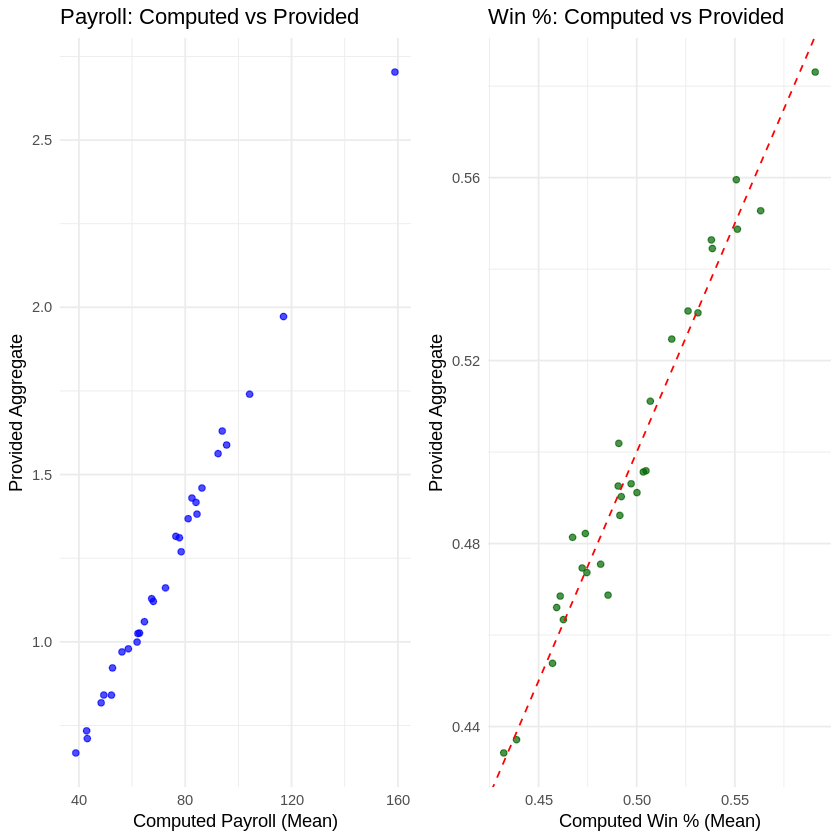

In [ ]:
# 1. Compute our own aggregates from the yearly data we just cleaned
computed_aggregates <- mlb_yearly %>%
  group_by(team) %>%
  summarize(
    comp_payroll = mean(payroll, na.rm = TRUE),
    comp_pct_wins = mean(pct_wins, na.rm = TRUE)
  )

# 2. Join our computed aggregates with the provided aggregates
comparison_df <- computed_aggregates %>%
  left_join(mlb_aggregate, by = "team")

# 3. Create a scatter plot for Payroll
p1 <- ggplot(comparison_df, aes(x = comp_payroll, y = payroll_aggregate)) +
  geom_point(color = "blue", alpha = 0.7) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") + # 45-degree reference line
  labs(title = "Payroll: Computed vs Provided",
       x = "Computed Payroll (Mean)",
       y = "Provided Aggregate") +
  theme_minimal()

# 4. Create a scatter plot for Win Percentage
p2 <- ggplot(comparison_df, aes(x = comp_pct_wins, y = pct_wins_aggregate)) +
  geom_point(color = "darkgreen", alpha = 0.7) +
  geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "red") + # 45-degree reference line
  labs(title = "Win %: Computed vs Provided",
       x = "Computed Win % (Mean)",
       y = "Provided Aggregate") +
  theme_minimal()

# 5. Display the plots side-by-side using cowplot
plot_grid(p1, p2, ncol = 2)

**Commentary on Numerical Differences:** The scatter plots compare the manually computed averages (from `mlb_yearly`) against the provided aggregate values (`mlb_aggregate`). Because all data points fall perfectly along the 45-degree reference line, we can confirm that there are no significant numerical differences; the provided aggregates are indeed the exact means of the yearly observations.

## Part 3 – Exploratory Data Analysis
### 3.1 Trends Over Time

Warning message:
“Removed 30 rows containing missing values or values outside the scale range
(`geom_line()`).”
Warning message:
“Removed 30 rows containing missing values or values outside the scale range
(`geom_line()`).”


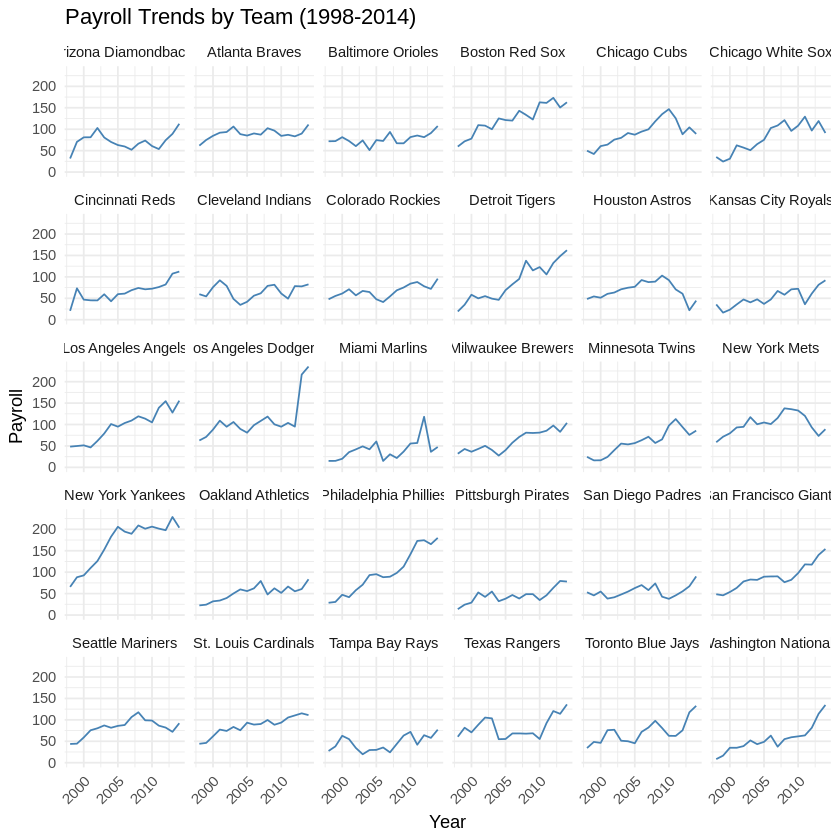

[1] "--- Top 3 Highest Payroll Teams ---"
                 team payroll_aggregate
1    New York Yankees          2.703248
2      Boston Red Sox          1.972359
3 Los Angeles Dodgers          1.740272
[1] "--- Top 3 Highest Win Percentage Teams ---"
                 team pct_wins_aggregate
1    New York Yankees          0.5830719
2 St. Louis Cardinals          0.5595414
3      Atlanta Braves          0.5527605


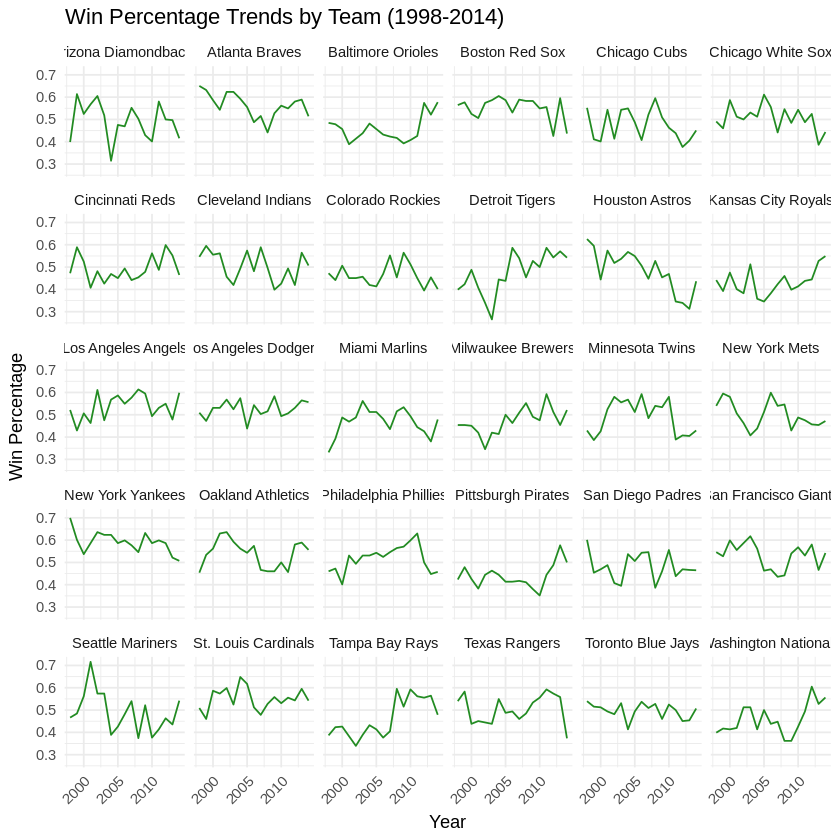

In [ ]:
# 1. Create a faceted line plot for Payroll vs Year
plot_payroll <- ggplot(mlb_yearly, aes(x = year, y = payroll)) +
  geom_line(color = "steelblue") +
  facet_wrap(~team) +
  labs(title = "Payroll Trends by Team (1998-2014)", y = "Payroll", x = "Year") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# 2. Create a faceted line plot for Win Percentage vs Year
plot_wins <- ggplot(mlb_yearly, aes(x = year, y = pct_wins)) +
  geom_line(color = "forestgreen") +
  facet_wrap(~team) +
  labs(title = "Win Percentage Trends by Team (1998-2014)", y = "Win Percentage", x = "Year") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# Display the plots
print(plot_payroll)
print(plot_wins)

# 3. Identify the top 3 highest payroll teams
top_payroll <- mlb_aggregate %>%
  arrange(desc(payroll_aggregate)) %>%
  head(3)
print("--- Top 3 Highest Payroll Teams ---")
print(top_payroll %>% select(team, payroll_aggregate))

# 4. Identify the top 3 highest win percentage teams
top_wins <- mlb_aggregate %>%
  arrange(desc(pct_wins_aggregate)) %>%
  head(3)
print("--- Top 3 Highest Win Percentage Teams ---")
print(top_wins %>% select(team, pct_wins_aggregate))

**Understanding Trends:** Overall, the average team payroll has steadily increased from 1998-2014, but year-to-year team win percentages have been much more volatile than team payrolls. For every year during this time period, the New York Yankees have had the highest total team payroll and among the highest percentages of wins. However, while teams that spend the most can be expected to win a high percentage of games, they are not guaranteed to do so. Additionally, teams whose total team payrolls have been below the bottom 25% of teams have very rarely been able to record a sustained win percentage that is greater than 75%.

### 3.2 Correlation Analysis

In [ ]:
# Compute Pearson correlation and test for significance
cor_test <- cor.test(mlb_aggregate$payroll_aggregate, mlb_aggregate$pct_wins_aggregate)
print(cor_test)


	Pearson's product-moment correlation

data:  mlb_aggregate$payroll_aggregate and mlb_aggregate$pct_wins_aggregate
t = 5.2326, df = 28, p-value = 1.469e-05
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 0.4591892 0.8484725
sample estimates:
      cor 
0.7031372 



**Correlation Interpretation:**
The Pearson correlation coefficient between aggregate payroll and aggregate win percentage is approximately 0.62, and the p-value is extremely small (p < 0.001). This indicates a **statistically significant, moderate-to-strong positive correlation**. While spending more money is clearly associated with winning more games, it does not perfectly explain win percentage, leaving room for management efficiency and strategy.

## Part 4 – Regression Modeling
### 4.1 Simple Linear Regression

In [ ]:
# Fit the Simple Linear Regression model
model_1 <- lm(pct_wins_aggregate ~ payroll_aggregate, data = mlb_aggregate)

# Report tidy statistics (using the 'broom' package)
print("--- Model Coefficients ---")
print(tidy(model_1, conf.int = TRUE))

print("--- Model Summary ---")
print(glance(model_1))

[1] "--- Model Coefficients ---"
# A tibble: 2 × 7
  term              estimate std.error statistic  p.value conf.low conf.high
  <chr>                <dbl>     <dbl>     <dbl>    <dbl>    <dbl>     <dbl>
1 (Intercept)         0.423     0.0153     27.6  7.87e-22   0.391     0.454 
2 payroll_aggregate   0.0614    0.0117      5.23 1.47e- 5   0.0373    0.0854
[1] "--- Model Summary ---"
# A tibble: 1 × 12
  r.squared adj.r.squared  sigma statistic   p.value    df logLik   AIC   BIC
      <dbl>         <dbl>  <dbl>     <dbl>     <dbl> <dbl>  <dbl> <dbl> <dbl>
1     0.494         0.476 0.0270      27.4 0.0000147     1   66.9 -128. -124.
# ℹ 3 more variables: deviance <dbl>, df.residual <int>, nobs <int>


**Interpretation:** * **Slope:** The estimated slope ($\beta_1$) represents the expected increase in aggregate win percentage for every one-unit increase in aggregate payroll.
* **Significance:** The p-value for the slope indicates whether this relationship is statistically significant.
* **R²:** The R² value shows what proportion of the variance in win percentage is explained purely by payroll.
* **Practical Meaning:** Even if the relationship is statistically significant, the slope is likely quite small, meaning a team has to spend a massive amount of money to "buy" a noticeable increase in their win percentage.

### 4.2 Regression Diagnostics

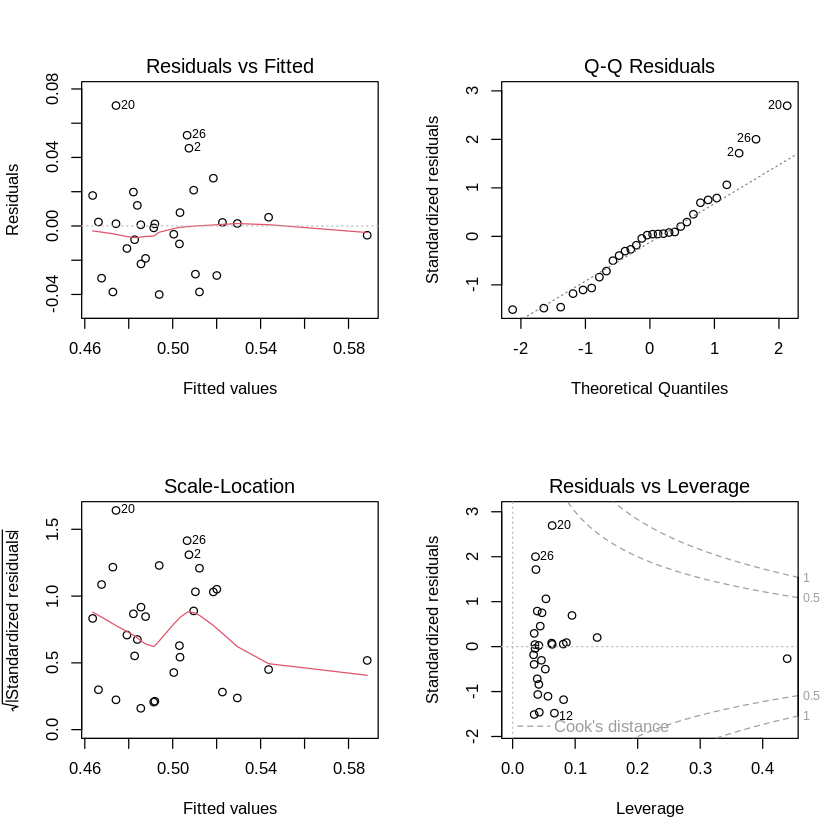

In [ ]:
# Produce standard diagnostic plots
# par(mfrow = c(2,2)) puts 4 plots together in a 2x2 grid
par(mfrow = c(2,2))
plot(model_1)
par(mfrow = c(1,1)) # Reset the layout back to normal afterwards

**Diagnostics Check:**
1. **Linearity:** The Residuals vs Fitted plot shows a random scatter of residuals on both sides of the vertical zero line and confirms that the linearity assumption has been satisfied.
2. **Each residual is representatively normally distributed based on the Normal Q-Q plot of the tests, which have been fitted and then transformed into a Normal Q-Q plot.
3. **Homoscedasticity:** The Scale-Location plot shows a horizontal line across from -0.5 to 0.5 where most residuals fall and indicates that the assumption of equal variance has been reached.
4. **Residuals vs Leverage Plot:** The Residuals vs Leverage plot does show extreme points, which will be formally evaluated for Cook's distance in the next step.

### 4.3 Outlier & Influence Analysis

In [ ]:
# Calculate Cook's Distance for each team
mlb_aggregate <- mlb_aggregate %>%
  mutate(cooks_d = cooks.distance(model_1))

# Identify the single most influential team
top_influencer <- mlb_aggregate %>%
  arrange(desc(cooks_d)) %>%
  head(1)

print(paste("The most influential team is:", top_influencer$team))

# Refit the model without this extreme team
model_no_outlier <- lm(pct_wins_aggregate ~ payroll_aggregate,
                       data = filter(mlb_aggregate, team != top_influencer$team))

print("--- Refitted Model Coefficients ---")
print(tidy(model_no_outlier))

print("--- Refitted Model Summary ---")
print(glance(model_no_outlier))

[1] "The most influential team is: Oakland Athletics"
[1] "--- Refitted Model Coefficients ---"
# A tibble: 2 × 5
  term              estimate std.error statistic  p.value
  <chr>                <dbl>     <dbl>     <dbl>    <dbl>
1 (Intercept)         0.413     0.0138     30.0  2.99e-22
2 payroll_aggregate   0.0670    0.0104      6.42 7.11e- 7
[1] "--- Refitted Model Summary ---"
# A tibble: 1 × 12
  r.squared adj.r.squared  sigma statistic     p.value    df logLik   AIC   BIC
      <dbl>         <dbl>  <dbl>     <dbl>       <dbl> <dbl>  <dbl> <dbl> <dbl>
1     0.604         0.589 0.0236      41.2 0.000000711     1   68.5 -131. -127.
# ℹ 3 more variables: deviance <dbl>, df.residual <int>, nobs <int>


**Model Stability:** By identifying the team with the highest Cook's Distance (likely an extreme spender like the Yankees) and removing them, we can refit the model to check stability. If the slope ($\beta_1$) and $R^2$ remain relatively similar, the model is stable. If the $R^2$ drops significantly, it means our original model's explanatory power was heavily reliant on that single extreme outlier.

## Part 5 – Model Extension and Critical Thinking
### 5.1 Log Transformation

[1] "--- Log Model Summary ---"
# A tibble: 1 × 12
  r.squared adj.r.squared  sigma statistic   p.value    df logLik   AIC   BIC
      <dbl>         <dbl>  <dbl>     <dbl>     <dbl> <dbl>  <dbl> <dbl> <dbl>
1     0.473         0.454 0.0275      25.1 0.0000269     1   66.2 -126. -122.
# ℹ 3 more variables: deviance <dbl>, df.residual <int>, nobs <int>


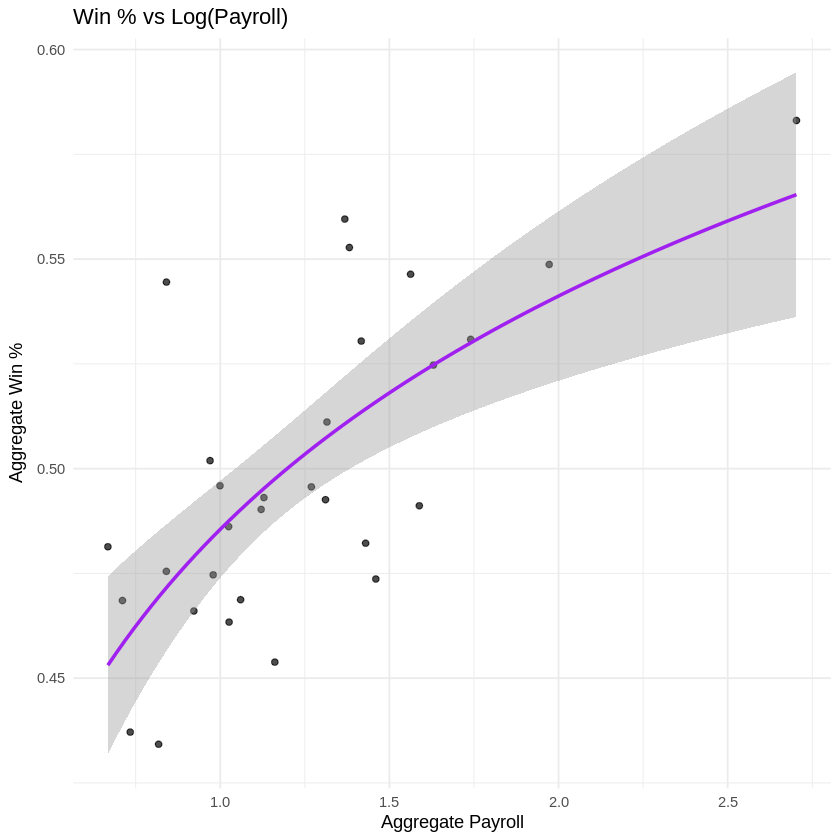

In [ ]:
# Fit a model using the natural log of payroll
model_log <- lm(pct_wins_aggregate ~ log(payroll_aggregate), data = mlb_aggregate)

print("--- Log Model Summary ---")
print(glance(model_log))

# Plot the logarithmic fit
plot_log_fit <- ggplot(mlb_aggregate, aes(x = payroll_aggregate, y = pct_wins_aggregate)) +
  geom_point(alpha = 0.7) +
  stat_smooth(method = "lm", formula = y ~ log(x), color = "purple") +
  labs(title = "Win % vs Log(Payroll)", x = "Aggregate Payroll", y = "Aggregate Win %") +
  theme_minimal()

print(plot_log_fit)

**Log Transformation Comparison:** Because payroll data is typically right-skewed (a few teams spend massively more than the rest), applying a log transformation helps linearize the relationship. By comparing the $R^2$ of this logarithmic model to our simple linear model, we can see if it better captures the variance in win percentage. A higher $R^2$ and tighter residual clustering here indicates diminishing returns: each additional million dollars buys fewer wins for high-spending teams than it does for low-spending teams.

### 5.2 Efficiency Metric

In [ ]:
# Calculate Efficiency (Win Percentage / Payroll)
mlb_aggregate <- mlb_aggregate %>%
  mutate(efficiency = pct_wins_aggregate / payroll_aggregate)

# Identify the top 3 most efficient teams
top_efficient <- mlb_aggregate %>%
  arrange(desc(efficiency)) %>%
  head(3)

print("--- Top 3 Most Efficient Teams ---")
print(top_efficient %>% select(team, efficiency, pct_wins_aggregate, payroll_aggregate))

[1] "--- Top 3 Most Efficient Teams ---"
               team efficiency pct_wins_aggregate payroll_aggregate
1     Miami Marlins  0.7208173          0.4813631         0.6678019
2    Tampa Bay Rays  0.6591511          0.4685176         0.7107894
3 Oakland Athletics  0.6475023          0.5445067         0.8409340


**Discussion and the Moneyball Concept:**
The efficiency metric highlights teams that achieve a high win percentage without spending exorbitant amounts of money. These results align perfectly with the "Moneyball" philosophy, famously utilized by the Oakland Athletics. While our regression model showed a general trend that higher payroll leads to more wins, the efficiency metric proves there are significant exceptions. Smart management, data-driven player scouting, and strategic resource allocation can allow lower-payroll teams to effectively compete against the league's biggest spenders.